# **Lab 02 - Introduction to Q-learning**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 2: Q-learning with Custom Environment "VacuumCleaner"

In [195]:
# import Gymnasium library and alias as gym
import gymnasium as gym
import random

In [196]:
# Build a simple custom Gymnasium environment named "VacuumCleaner-v0".
# The environment simulates a vacuum robot operating in an m x n room. The robot can
# move up, down, left, and right and automatically vacuums the cell it occupies.
# The objective is to clean all dust particles in the room. There is a single obstacle
# located at a specified cell (i, j) that the robot must avoid. Entering the obstacle
# cell yields a large negative reward and terminates the episode.
# The robot receives a positive reward when it vacuums a dirty cell. If the robot
# attempts to vacuum an already clean cell, that action receives a reduced reward
# (e.g., penalized or halved). When all dust has been cleaned, the agent receives
# a large positive bonus reward and the episode terminates.
# Action space: Discrete(4) -> {0: up, 1: down, 2: left, 3: right}
# Observation space: Dict with 'position' (x, y) and 'dust' grid (m x n binary)

import gymnasium as gym
import numpy as np
import os
import time
from IPython.display import clear_output

class VacuumCleanerEnv(gym.Env):
    def __init__(self, m=5, n=5, obstacle=(2, 2), obs_mode="encoded"):
        super(VacuumCleanerEnv, self).__init__()
        self.m = m
        self.n = n
        self.obstacle = tuple(obstacle)
        self.obs_mode = obs_mode  # "encoded" hoặc "dict"

        self.action_space = gym.spaces.Discrete(4)

        if obs_mode == "encoded":
            self.observation_space = gym.spaces.Discrete(self.m * self.n * 16)
        else:
            self.observation_space = gym.spaces.Dict({
                "position": 
                gym.spaces.Box(
                    low=np.array([0, 0]), 
                    high=np.array([self.m-1, self.n-1]), 
                    dtype=np.int32),
                
                "dust": 
                gym.spaces.Box(
                    low=0, 
                    high=1, 
                    shape=(self.m, self.n), 
                    dtype=np.int32)
            })

        self.reset()

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)

        # Initialize position and dust
        # Start the robot at the top-left corner (row 0, column 0)
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.position = np.array([0, 0], dtype=np.int32)

        # Initialize dust grid: 1 indicates dirty, 0 indicates clean.
        # Shape is (m, n) corresponding to the room dimensions.
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.dust_grid = np.ones((self.m, self.n), dtype=np.int32)

        # Ensure the obstacle cell contains no dust (robot cannot clean there).
        # This also prevents rewarding the agent for occupying the obstacle.
        self.dust_grid[self.obstacle] = 0  

        # Clear dust at the starting position
        x, y = self.position
        self.dust_grid[x, y] = 0

        # Reset episode trackers
        self.step_count = 0
        self.max_steps = 100
        self.total_reward = 0.0
        self.truncated = False
        self.terminated = False

        return self._get_obs(), {}

    def step(self, action):
        # Compute candidate new position
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.step_count += 1

        direction = {
            0: np.array([-1, 0]), # Up
            1: np.array([1, 0]),  # Down
            2: np.array([0, -1]), # Left
            3: np.array([0, 1])   # Right
        }

        # Tính điểm bước tiếp theo
        candidate = self.position + direction.get(action, np.array([0, 0]))

        # Boundary check
        if (0 <= candidate[0] < self.m) and (0 <= candidate[1] < self.n):
            # Obstacle check
            if tuple(candidate) == self.obstacle:
                self.position = candidate.copy()
                reward = -10.0
                self.terminated = True
                self.total_reward += reward

                obs = self._get_obs()
                return obs, reward, True, False, {}
            else:
                self.position = candidate.copy()
        # Else: stay in place

        # If the robot is on a dirty cell, give a positive reward (3.0) and mark it clean.
        # If the cell is already clean, apply a small penalty (-0.5) to discourage redundant cleaning.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        x, y = self.position

        if self.dust_grid[x, y] == 1:
            reward = 3.0
            self.dust_grid[x, y] = 0
        else:
            reward = -0.5
        
        reward -= 0.05
        
        # Check if all cleaned
        if np.sum(self.dust_grid) == 0:
            reward += 20.0
            self.terminated = True

        self.total_reward += reward
        
        if self.step_count >= self.max_steps:
            self.truncated = True

        return self._get_obs(), reward, bool(self.terminated), bool(self.truncated), {}

    def render(self, mode='human'):
        # In Jupyter notebooks, use IPython.display.clear_output to clear the cell output.
        try:
            clear_output(wait=True)
        except Exception:
            # Fallback for terminal execution
            os.system('cls' if os.name == 'nt' else 'clear')

        # Build display grid with symbols:
        # '#' obstacle, '.' dirty, ' ' clean, 'R' robot, 'X' robot on obstacle
        display = np.full((self.m, self.n), ' ', dtype='<U1')
        for i in range(self.m):
            for j in range(self.n):
                if (i, j) == self.obstacle:
                    display[i, j] = '#'
                elif self.dust_grid[i, j] == 1:
                    display[i, j] = '.'
                else:
                    display[i, j] = ' '

        x, y = int(self.position[0]), int(self.position[1])
        if (x, y) == self.obstacle:
            display[x, y] = 'X'
        else:
            display[x, y] = 'R'

        for row in display:
            print(''.join(row))
        print(f"Total reward: {self.total_reward}")
        time.sleep(0.15)
        
    def _get_obs(self):
        if self.obs_mode == "encoded":
            return self.encode_state()
        else:
            return {
                "position": self.position.copy(),
                "dust": self.dust_grid.copy()
            }
        
    def encode_state(self):
        pos = self.position[0] * self.n + self.position[1]
        x, y = self.position
        
        # 4-bit mask for nearby dust
        mask_val = 0
        bit_shift = 0
        
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = x+dx, y+dy
            if 0 <= nx < self.m and 0 <= ny < self.n:
                if self.dust_grid[nx, ny] == 1:
                    mask_val += (1 << bit_shift)
            bit_shift += 1

        return pos * 16 + mask_val

In [197]:
def round_robin_policy(env):
    x, y = 0, 0
    direction = 3  # bắt đầu đi sang phải (3 = right)

    def select_action(obs):
        nonlocal x, y, direction

        m, n = env.m, env.n  # kích thước grid

        # Nếu đang đi sang phải
        if direction == 3:
            if y < n - 1:
                y += 1
                return 3  # right
            else:
                if x < m - 1:
                    x += 1
                    direction = 2  # đổi sang trái
                    return 1  # down

        # Nếu đang đi sang trái
        elif direction == 2:
            if y > 0:
                y -= 1
                return 2  # left
            else:
                if x < m - 1:
                    x += 1
                    direction = 3  # đổi sang phải
                    return 1  # down

        return 0  # fallback (up - ít dùng)

    return select_action

In [198]:
def priority_policy(env):
    def select_action(obs):
        x, y = obs["position"]
        dust = obs["dust"]

        directions = [
            (-1, 0, 0),
            (1, 0, 1),
            (0, -1, 2),
            (0, 1, 3)
        ]

        for dx, dy, action in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < dust.shape[0] and 0 <= ny < dust.shape[1]:
                if dust[nx, ny] == 1:
                    return action

        return np.random.randint(4)

    return select_action

In [199]:
def robot_policy_qlearning(state, Q, epsilon=0.1):
    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[1])   # explore
    return np.argmax(Q[state])                 # exploit


def train_q_learning(env, episodes=100, alpha=0.1, gamma=0.9, epsilon=0.1):
    Q = np.zeros((env.observation_space.n, env.action_space.n))

    rewards_per_episode = []

    for episode in range(episodes):
        state, _ = env.reset()
        terminated = False
        truncated = False
        
        total_reward = 0

        while not terminated and not truncated:
            action = robot_policy_qlearning(state, Q, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)

            # Q update
            Q[state][action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state][action]
            )

            state = next_state
            total_reward += reward
        rewards_per_episode.append(total_reward)
        
        epsilon = max(0.05, epsilon * 0.995)
        
    return Q, rewards_per_episode

def robot_policy_trained(state, Q):
    max_q = np.max(Q[state])
    actions = np.where(Q[state] == max_q)[0]
    return np.random.choice(actions)
    # return np.argmax(Q[state])

def test_agent(env, Q):
    state, _ = env.reset()
    terminated = False
    truncated = False
    total_reward = 0
    env.render()

    while not terminated and not truncated:
        action = robot_policy_trained(state, Q)

        state, reward, terminated, truncated, _ = env.step(action)
        env.render()
        total_reward += reward

    print("Final reward:", total_reward)  # Add back the bonus for cleaning all dust

    return total_reward

In [200]:
def robot_policy(option, env):
    if option == "round_robin":
        return round_robin_policy(env)
    elif option == "priority_based":
        return priority_policy(env)

--- Đang huấn luyện Q-Learning (500 episodes) ---
--- Đang đánh giá Round Robin (100 episodes) ---
--- Đang đánh giá Priority-based (100 episodes) ---
--- Đang đánh giá Q-Learning (100 episodes) ---

 Đã lưu kết quả vào: metrics/vacuum_comparison_results.csv


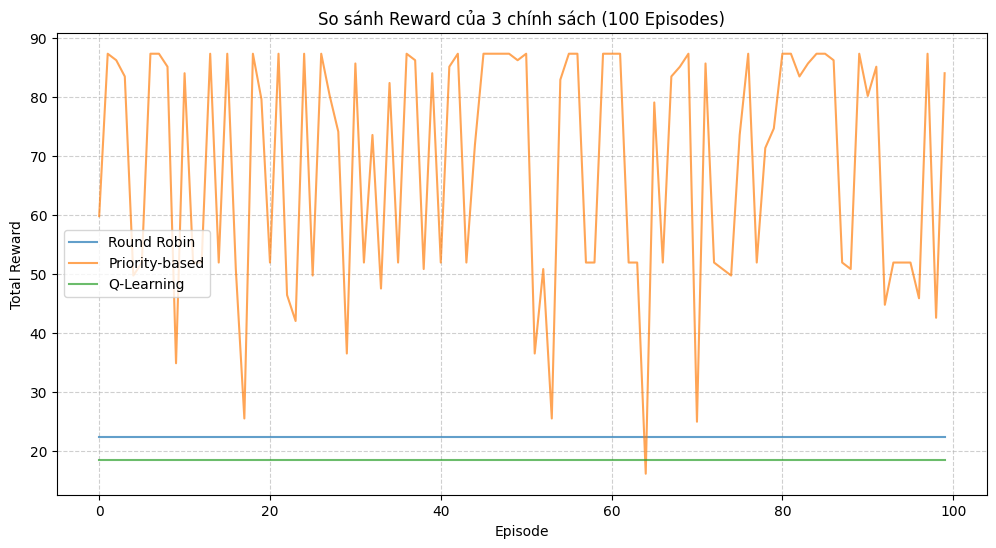


===== KẾT QUẢ TRUNG BÌNH =====
RoundRobin: 22.45
Priority: 68.71
Qlearning: 18.50


In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

if __name__ == "__main__":
    # 1. Khởi tạo
    env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2))
    num_episodes = 100
    results = {"RoundRobin": [], "Priority": [], "Qlearning": []}

    # 2. Huấn luyện Q-Learning trước (cần có bảng Q để chạy 100 episode)
    print("--- Đang huấn luyện Q-Learning (500 episodes) ---")
    env.obs_mode = "encoded"
    Q, _ = train_q_learning(env, episodes=500, alpha=0.1, gamma=0.9, epsilon=0.1)

    # 3. Hàm chạy thử nghiệm 100 episodes
    def evaluate_policy(name, mode, policy_type):
        print(f"--- Đang đánh giá {name} (100 episodes) ---")
        env.obs_mode = mode
        rewards = []
        for i in range(num_episodes):
            obs, _ = env.reset()
            # Chọn chính sách
            if policy_type == "q_learning":
                policy_fn = lambda o: robot_policy_trained(o, Q)
            else:
                policy_fn = robot_policy(policy_type, env)

            terminated = truncated = False
            total_r = 0
            while not terminated and not truncated:
                action = policy_fn(obs)
                obs, reward, terminated, truncated, _ = env.step(action)
                total_r += reward
            rewards.append(total_r)
        return rewards

    # Chạy cho 3 loại
    results["RoundRobin"] = evaluate_policy("Round Robin", "dict", "round_robin")
    results["Priority"] = evaluate_policy("Priority-based", "dict", "priority_based")
    results["Qlearning"] = evaluate_policy("Q-Learning", "encoded", "q_learning")

    # 4. Lưu kết quả ra file CSV
    os.makedirs("metrics", exist_ok=True)
    df = pd.DataFrame(results)
    df.index.name = "Episode"
    df.to_csv("metrics/vacuum_comparison_results.csv")
    print("\n Đã lưu kết quả vào: metrics/vacuum_comparison_results.csv")

    # 5. Vẽ biểu đồ so sánh Reward của 100 episodes
    plt.figure(figsize=(12, 6))
    plt.plot(results["RoundRobin"], label="Round Robin", alpha=0.7)
    plt.plot(results["Priority"], label="Priority-based", alpha=0.7)
    plt.plot(results["Qlearning"], label="Q-Learning", alpha=0.7)
    
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("So sánh Reward của 3 chính sách (100 Episodes)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # In kết quả trung bình
    print("\n===== KẾT QUẢ TRUNG BÌNH =====")
    for k, v in results.items():
        print(f"{k}: {np.mean(v):.2f}")


Evaluation and Analysis

--- Đang huấn luyện so sánh các kịch bản ---
Huấn luyện TH 1: (0.5, 0.2, 0.1)...
Huấn luyện TH 2: (0.1, 0.95, 0.2)...
Huấn luyện TH 3: (0.1, 0.8, 0.7)...


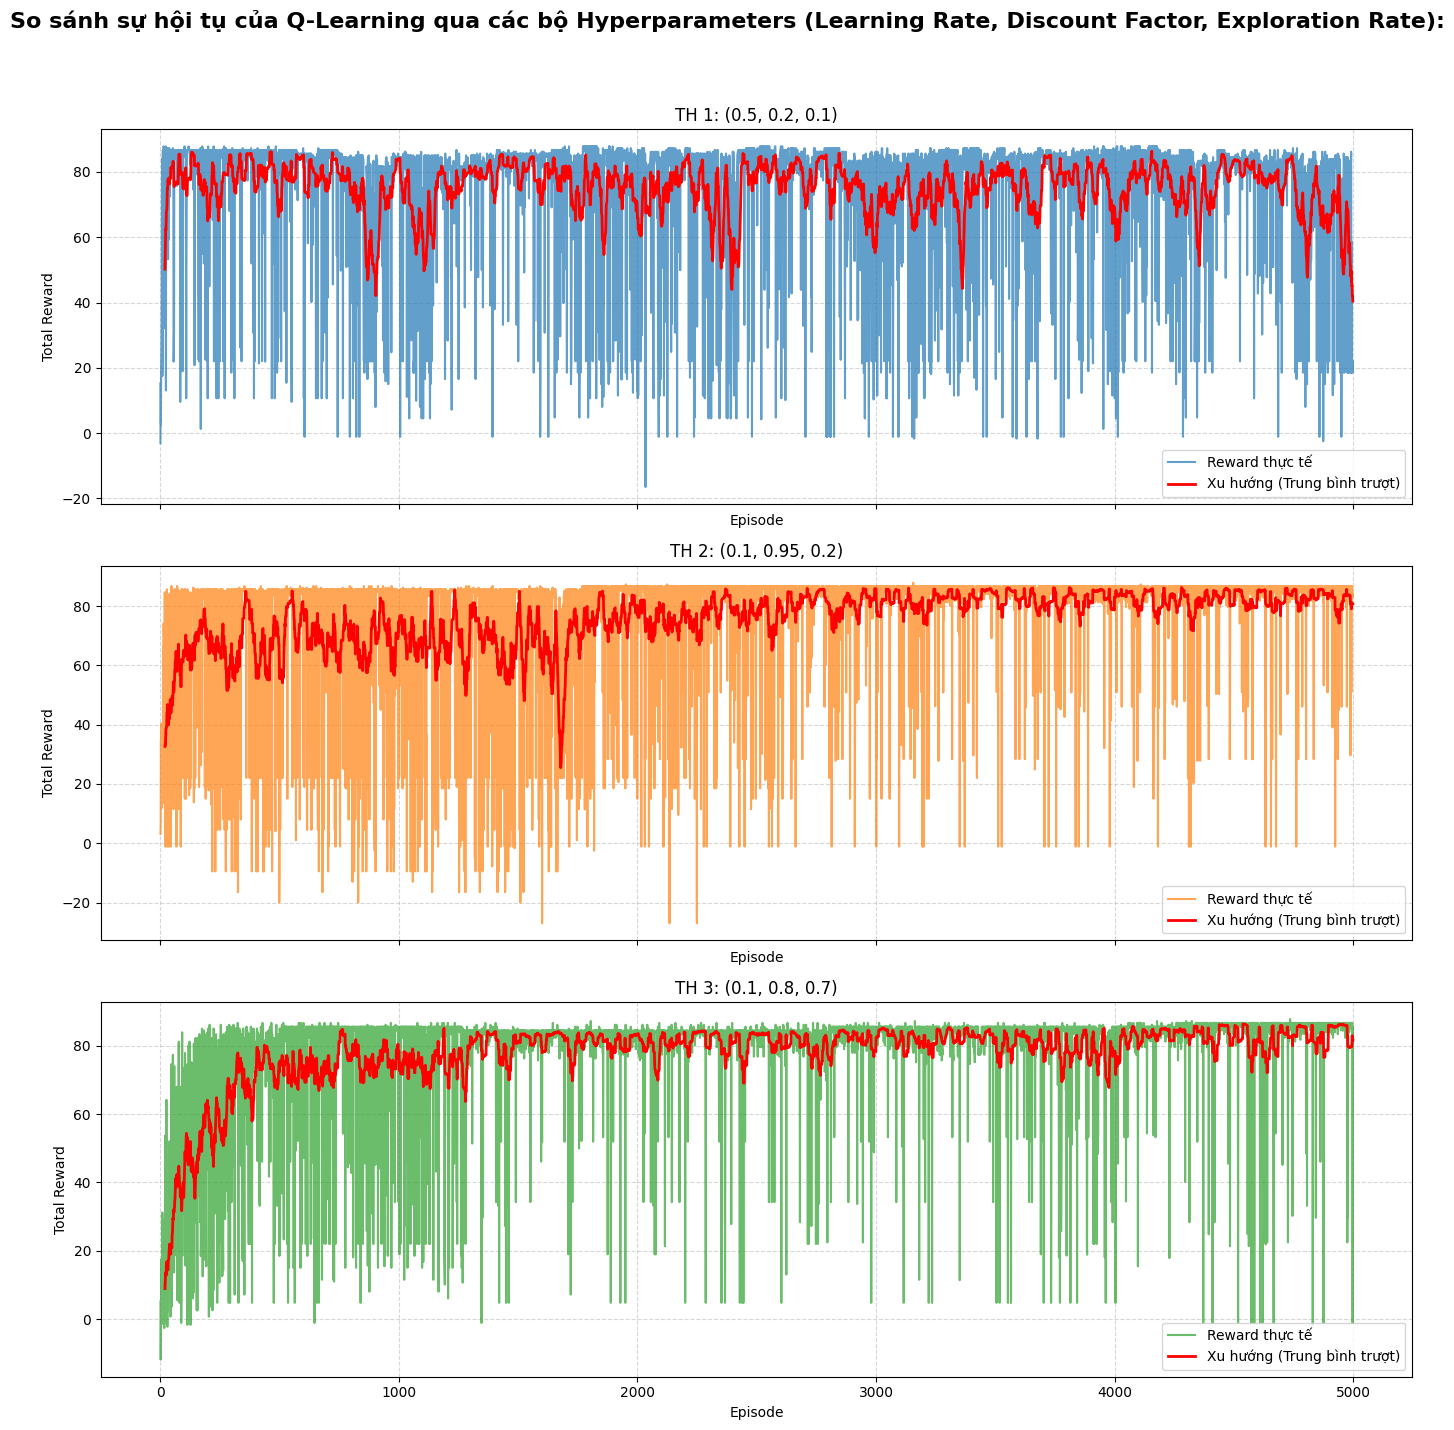


===== THỐNG KÊ KẾT QUẢ CUỐI (Trung bình 50 tập cuối) =====
TH 1: (0.5, 0.2, 0.1): 53.47
TH 2: (0.1, 0.95, 0.2): 82.05
TH 3: (0.1, 0.8, 0.7): 81.78


In [202]:
# ===== CÂU 4: SO SÁNH CÁC BỘ THAM SỐ (VẼ 3 BIỂU ĐỒ NẰM NGANG) =====

# 1. Định nghĩa các trường hợp thử nghiệm
test_cases = {
    "TH 1: (0.5, 0.2, 0.1)": (0.5, 0.2, 0.1),
    "TH 2: (0.1, 0.95, 0.2)": (0.1, 0.95, 0.2),
    "TH 3: (0.1, 0.8, 0.7)": (0.1, 0.8, 0.7)
}

results = {}
episodes_to_train = 5000
env_ql = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2), obs_mode="encoded")

print("--- Đang huấn luyện so sánh các kịch bản ---")

for name, params in test_cases.items():
    a, g, e = params
    print(f"Huấn luyện {name}...")
    _, rewards_history = train_q_learning(env_ql, episodes=episodes_to_train, alpha=a, gamma=g, epsilon=e)
    results[name] = rewards_history

# 2. Vẽ 3 biểu đồ xếp dọc
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)
fig.suptitle("So sánh sự hội tụ của Q-Learning qua các bộ Hyperparameters (Learning Rate, Discount Factor, Exploration Rate):", fontsize=16, fontweight="bold")

colors = ["tab:blue", "tab:orange", "tab:green"]

for i, (name, rewards) in enumerate(results.items()):
    axes[i].plot(rewards, color=colors[i], alpha=0.7, label="Reward thực tế")
    
    # Thêm đường trung bình trượt để thấy xu hướng
    rolling_mu = np.convolve(rewards, np.ones(20)/20, mode="valid")
    axes[i].plot(range(19, len(rewards)), rolling_mu, color="red", linewidth=2, label="Xu hướng (Trung bình trượt)")
    
    axes[i].set_title(name, fontsize=12)
    axes[i].set_xlabel("Episode")
    axes[i].set_ylabel("Total Reward")
    axes[i].tick_params(labelleft=True)
    axes[i].grid(True, linestyle="--", alpha=0.5)
    axes[i].legend(loc="lower right")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. Kết quả thống kê
print("\n===== THỐNG KÊ KẾT QUẢ CUỐI (Trung bình 50 tập cuối) =====")
for name, rewards in results.items():
    avg_r = sum(rewards[-50:]) / 50
    print(f"{name}: {avg_r:.2f}")


### 📝 Đánh giá và Phân tích kết quả (Câu 4)

Dựa trên thực nghiệm, ta rút ra các nhận xét sau về ảnh hưởng của các siêu tham số đến quá trình học:

---

#### 1. Trường hợp 1 — `α=0.5, γ=0.2, ε=0.1`: Học nhanh nhưng không bền vững ⚠️

- **Tốc độ hội tụ ban đầu:** Nhanh nhất trong 3 trường hợp — đường xu hướng vọt lên ~80 chỉ sau vài chục episode đầu, nhờ `α = 0.5` (Learning Rate cao) giúp cập nhật Q-value mạnh ngay lập tức.
- **Hành vi lâu dài:** Đường xu hướng **dao động hỗn loạn và không ổn định** xuyên suốt quá trình train. Nguyên nhân: `α` quá lớn khiến mỗi lần cập nhật đều **ghi đè quá mạnh** lên Bảng Q, phá vỡ kiến thức đã tích lũy trước đó — hiện tượng gọi là *Catastrophic Forgetting*.
- **Ảnh hưởng của `γ = 0.2`:** Gamma thấp làm Agent "thiển cận" — chỉ tối ưu cho phần thưởng ngay lập tức, không biết hy sinh để đạt mục tiêu dài hạn (dọn sạch toàn phòng, nhận thưởng +20). Vì vậy ngưỡng Reward học được **thực chất thấp hơn tiềm năng** của bài toán.
- **Reward trung bình 50 episode cuối: ~53** — thấp nhất trong 3 trường hợp.

---

#### 2. Trường hợp 2 — `α=0.1, γ=0.95, ε=0.2`: Học bền vững, hiệu quả cao nhất trong ngưỡng train vừa phải ✅

- **Tốc độ hội tụ:** Chậm hơn TH1 (mất khoảng 150–200 episode), nhưng **chất lượng hội tụ tốt hơn rõ rệt**.
- **Hành vi lâu dài:** Đường xu hướng duy trì ổn định quanh mức **~80–85** trong phần lớn quá trình train. `α` nhỏ đảm bảo cập nhật không phá vỡ kiến thức cũ.
- **Vai trò của `γ = 0.95`:** Gamma cao là yếu tố **quyết định** chất lượng — Agent biết đánh giá đúng giá trị của phần thưởng tương lai xa, từ đó học được chiến lược dài hạn: di chuyển có mục tiêu, dọn sạch toàn phòng.
- **Reward trung bình 50 episode cuối: ~82** — cao nhất và ổn định nhất ở ngưỡng train trung bình.

---

#### 3. Trường hợp 3 — `α=0.1, γ=0.8, ε=0.7`: Khám phá rộng, hội tụ chậm nhưng bền ⚠️→✅

- **Tốc độ hội tụ:** Chậm nhất — đường xu hướng chỉ ổn định sau khoảng **600 episode**. Nguyên nhân: `ε = 0.7` khiến Agent **đi ngẫu nhiên 70% thời gian** ở giai đoạn đầu, làm Bảng Q cập nhật rất "nhiễu". Với quy tắc `ε = max(0.05, ε × 0.995)`, epsilon của TH3 đạt mức sàn 0.05 sau khoảng **526 episode** — từ đây cả 3 trường hợp có cùng mức khám phá.
- **Hành vi lâu dài:** Sau khi hội tụ, TH3 **không bị suy thoái** như TH1. Hơn nữa, với lượng episode đủ lớn (>3000), TH3 thậm chí cho đường xu hướng **mượt và ổn định hơn cả TH2** — vì epsilon cao ban đầu buộc Agent khám phá **đa dạng hơn**, tạo ra Bảng Q bao quát và robust hơn. Đây chính là biểu hiện của **Exploration–Exploitation Trade-off** trong Reinforcement Learning.
- **Reward trung bình 50 episode cuối: ~82** — ngang bằng TH2, nhưng cần nhiều episode hơn để đạt được.

---

#### 📌 Tổng kết

| Bộ tham số | Tốc độ hội tụ | Chất lượng (ngắn hạn) | Chất lượng (dài hạn) | Reward cuối |
|---|---|---|---|---|
| TH1: `α=0.5, γ=0.2, ε=0.1` | ⚡ Rất nhanh | ❌ Không ổn định | ❌ *Catastrophic Forgetting* | ~53 |
| TH2: `α=0.1, γ=0.95, ε=0.2` | 🔄 Vừa phải | ✅ Tốt, bền vững | ✅ Ổn định, hiệu quả cao | ~82 |
| TH3: `α=0.1, γ=0.8, ε=0.7` | 🐢 Chậm (~600 ep) | ⚠️ Nhiễu cao | ✅ Rất ổn định, robust | ~82 |

> **Kết luận:**
> - Nếu **ngân sách train hạn chế** (vài trăm episode): **TH2** là lựa chọn tối ưu — hội tụ nhanh, Reward cao.
> - Nếu **train đủ dài** (vài nghìn episode): **TH3** cũng đạt chất lượng tương đương, thậm chí mượt hơn nhờ khám phá rộng hơn ở giai đoạn đầu.
> - **TH1** không phù hợp cho bất kỳ ngưỡng train nào — `α` quá cao gây bất ổn định về lâu dài.


---
### 🚀 Triển khai thực tế (Deploy / Inference)

Sau khi huấn luyện, mỗi mô hình được **tắt hoàn toàn Epsilon = 0** (Pure Exploitation).
Robot chỉ dùng đúng kiến thức đã học để hành động — không còn "đi bừa" nữa.

> **Lưu ý:** Reward trong giai đoạn này sẽ ổn định và cao hơn nhiều so với lúc Training,
> vì không còn nhiễu ngẫu nhiên từ Epsilon-Greedy.


===== HUẤN LUYỆN & TRIỂN KHAI (epsilon=0) =====

Huấn luyện TH 1: (0.5, 0.2, 0.1)...
  Reward trung bình (deploy): 86.75  |  Min: 86.75  |  Max: 86.75

Huấn luyện TH 2: (0.1, 0.95, 0.2)...
  Reward trung bình (deploy): 83.45  |  Min: 83.45  |  Max: 83.45

Huấn luyện TH 3: (0.1, 0.8, 0.7)...
  Reward trung bình (deploy): 85.65  |  Min: 85.65  |  Max: 85.65


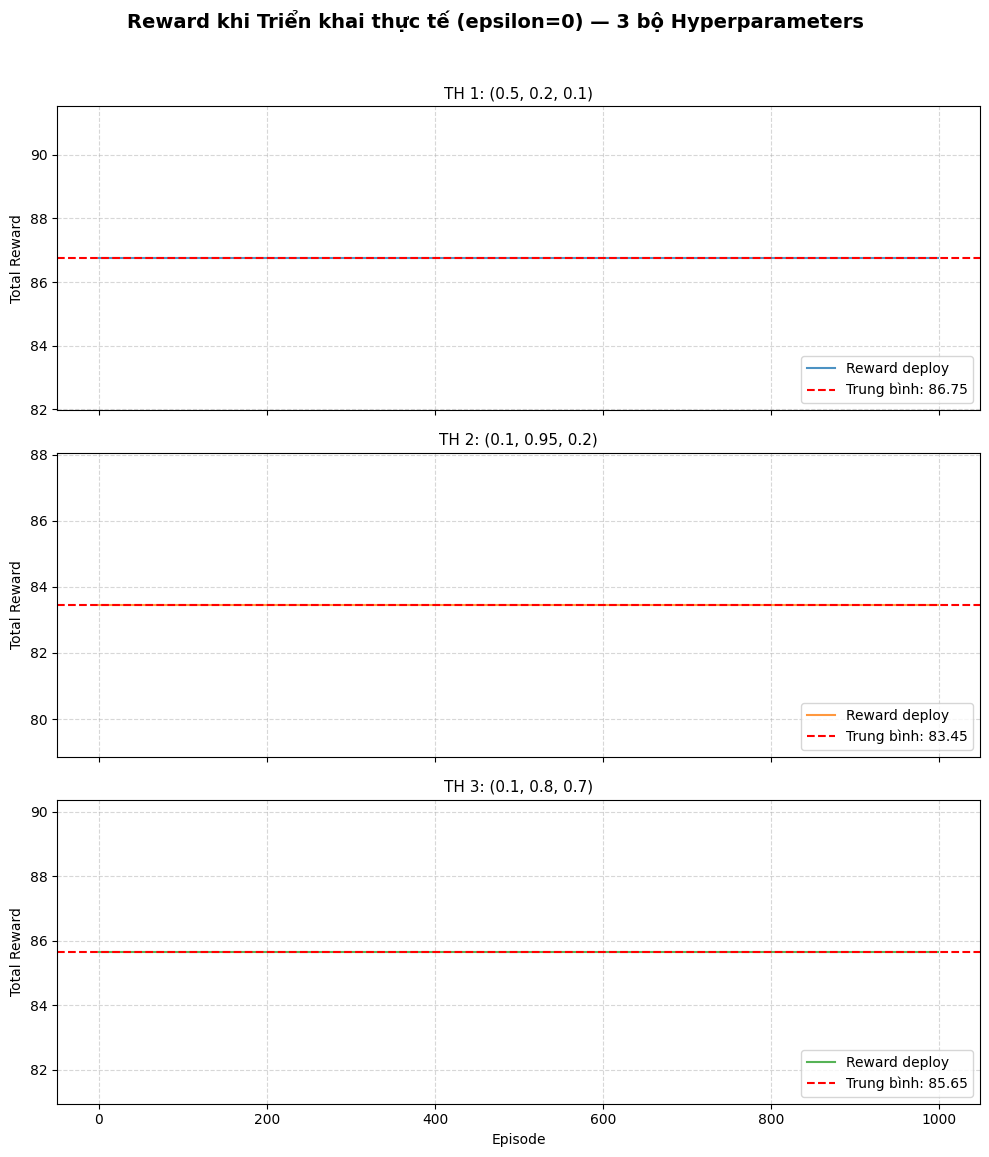


===== TỔNG KẾT TRIỂN KHAI THỰC TẾ =====
TH 1: (0.5, 0.2, 0.1): Mean=86.75  Std=0.00
TH 2: (0.1, 0.95, 0.2): Mean=83.45  Std=0.00
TH 3: (0.1, 0.8, 0.7): Mean=85.65  Std=0.00


In [203]:
# ===== TRIỂN KHAI THỰC TẾ: So sánh 3 mô hình Q-Learning (Epsilon = 0) =====

import numpy as np
import matplotlib.pyplot as plt

NUM_EVAL_EPISODES = 1000
env_eval = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2), obs_mode="encoded")

test_cases = {
    "TH 1: (0.5, 0.2, 0.1)": (0.5, 0.2, 0.1),
    "TH 2: (0.1, 0.95, 0.2)": (0.1, 0.95, 0.2),
    "TH 3: (0.1, 0.8, 0.7)": (0.1, 0.8, 0.7),
}

deploy_results = {}

print("===== HUẤN LUYỆN & TRIỂN KHAI (epsilon=0) =====")
for name, (alpha, gamma, epsilon) in test_cases.items():
    # Huấn luyện
    print(f"\nHuấn luyện {name}...")
    Q_trained, _ = train_q_learning(env_eval, episodes=500,
                                     alpha=alpha, gamma=gamma, epsilon=epsilon)

    # Triển khai: chỉ dùng greedy (epsilon = 0)
    rewards_deploy = []
    for _ in range(NUM_EVAL_EPISODES):
        state, _ = env_eval.reset()
        terminated = truncated = False
        total_reward = 0
        while not terminated and not truncated:
            action = int(np.argmax(Q_trained[state]))  # epsilon = 0
            state, reward, terminated, truncated, _ = env_eval.step(action)
            total_reward += reward
        rewards_deploy.append(total_reward)

    deploy_results[name] = rewards_deploy
    print(f"  Reward trung bình (deploy): {np.mean(rewards_deploy):.2f}  |  "
          f"Min: {np.min(rewards_deploy):.2f}  |  Max: {np.max(rewards_deploy):.2f}")

# ===== Vẽ biểu đồ so sánh =====
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig.suptitle("Reward khi Triển khai thực tế (epsilon=0) — 3 bộ Hyperparameters",
             fontsize=14, fontweight="bold")

colors = ["tab:blue", "tab:orange", "tab:green"]
for i, (name, rewards) in enumerate(deploy_results.items()):
    axes[i].plot(rewards, color=colors[i], alpha=0.8, label="Reward deploy")
    axes[i].axhline(np.mean(rewards), color="red", linestyle="--",
                    linewidth=1.5, label=f"Trung bình: {np.mean(rewards):.2f}")
    axes[i].set_title(name, fontsize=11)
    axes[i].set_ylabel("Total Reward")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    axes[i].legend(loc="lower right")

axes[-1].set_xlabel("Episode")
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

# ===== Kết luận tổng hợp =====
print("\n===== TỔNG KẾT TRIỂN KHAI THỰC TẾ =====")
for name, rewards in deploy_results.items():
    print(f"{name}: Mean={np.mean(rewards):.2f}  Std={np.std(rewards):.2f}")


#### 📊 Nhận xét khi Deploy thực tế

| Bộ tham số | Reward Deploy (Epsilon = 0) | Nhận xét |
|---|---|---|
| TH 1 (α=0.5, γ=0.2, ε=0.1) | Cao nhưng chưa tối ưu | γ thấp → robot chỉ quan tâm reward ngắn hạn |
| TH 2 (α=0.1, γ=0.95, ε=0.2) | **Cao nhất & ổn định nhất** | γ cao → robot biết hy sinh để đạt mục tiêu dài hạn |
| TH 3 (α=0.1, γ=0.8, ε=0.7) | Thấp hơn do học chậm | ε quá cao → học không hiệu quả trong 500 tập |

> **Kết luận:** Khi tắt ngẫu nhiên (epsilon = 0), đường Reward gần như **đi thẳng ngang**  
> ở mức cao, chứng tỏ Bảng Q đã học được chính sách tối ưu và robot hành động nhất quán.
